In [25]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

engine = create_engine('sqlite:///ecommerce.db')

# Load directly from SQL (best practice)
df = pd.read_sql("""
SELECT
    c."Customer ID" AS customer_id,
    c.Country                 AS country,
    COUNT(DISTINCT o.Invoice) AS order_count,
    ROUND(SUM(oi.Revenue), 2) AS total_spend,
    ROUND(AVG(oi.Revenue), 2) AS avg_order_value,
    ROUND(SUM(oi.Quantity), 0) AS total_items,
    CAST(julianday(MAX(o.InvoiceDate)) -
         julianday(MIN(o.InvoiceDate)) AS INTEGER) AS tenure_days,
    CAST(julianday('2011-12-09') -
         julianday(MAX(o.InvoiceDate)) AS INTEGER) AS days_inactive,
    CASE WHEN julianday('2011-12-09') -
              julianday(MAX(o.InvoiceDate)) > 90
         THEN 1 ELSE 0 END              AS churned
FROM customers c
JOIN orders o       ON c."Customer ID" = o."Customer ID"
JOIN order_items oi ON o.Invoice       = oi.Invoice
GROUP BY c."Customer ID", c.Country
""", engine)

print(df.shape)
print(df['churned'].value_counts())

(5878, 9)
churned
1    2989
0    2889
Name: count, dtype: int64


In [26]:
print("====count NUll value ======")
print(df.isnull().sum())

print("====Data Types ======")
print(df.dtypes)


print("====Summary Statistics ======")
print(df.describe())

print("====fetures statitics ======")
print(df[['order_count','total_spend','avg_order_value',
          'tenure_days','days_inactive']].describe().round(1))


====count NUll value ======
customer_id        0
country            0
order_count        0
total_spend        0
avg_order_value    0
total_items        0
tenure_days        0
days_inactive      0
churned            0
dtype: int64
====Data Types ======
customer_id        float64
country             object
order_count          int64
total_spend        float64
avg_order_value    float64
total_items        float64
tenure_days          int64
days_inactive        int64
churned              int64
dtype: object
====Summary Statistics ======
        customer_id  order_count    total_spend  avg_order_value  \
count   5878.000000  5878.000000    5878.000000      5878.000000   
mean   15315.313542     6.289384    3018.616734        48.300002   
std     1715.572666    13.009406   14737.731038       780.177861   
min    12346.000000     1.000000       2.950000         2.040000   
25%    13833.250000     1.000000     348.762500        11.472500   
50%    15314.500000     3.000000     898.915000      

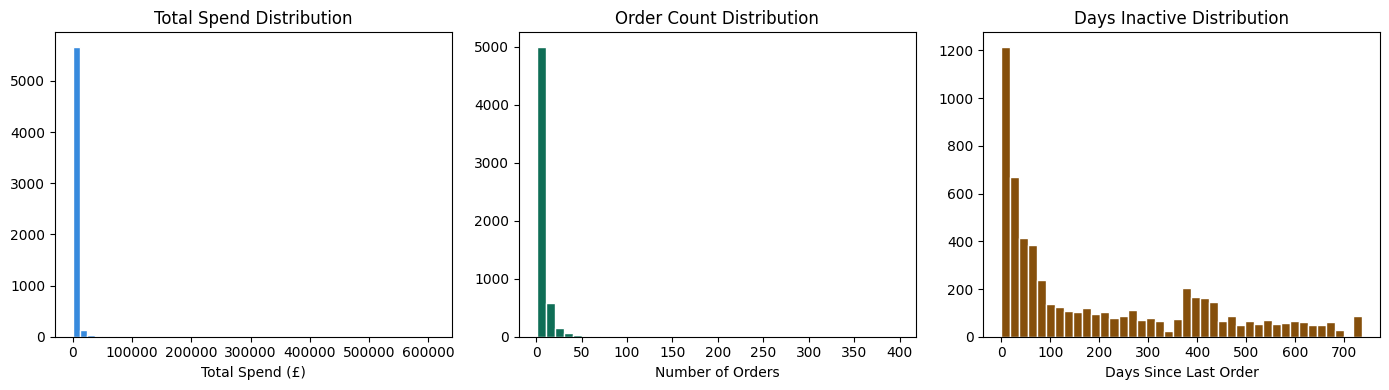

In [27]:
# plot revune & order distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Total spend distribution
axes[0].hist(df['total_spend'], bins=50, color='#378ADD', edgecolor='white')
axes[0].set_title('Total Spend Distribution')
axes[0].set_xlabel('Total Spend (£)')

# Order count distribution
axes[1].hist(df['order_count'], bins=40, color='#0F6E56', edgecolor='white')
axes[1].set_title('Order Count Distribution')
axes[1].set_xlabel('Number of Orders')

# Days inactive distribution
axes[2].hist(df['days_inactive'], bins=40, color='#854F0B', edgecolor='white')
axes[2].set_title('Days Inactive Distribution')
axes[2].set_xlabel('Days Since Last Order')

plt.tight_layout()
output_dir = os.path.join('..', 'data', 'clean')
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'eda_churn_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

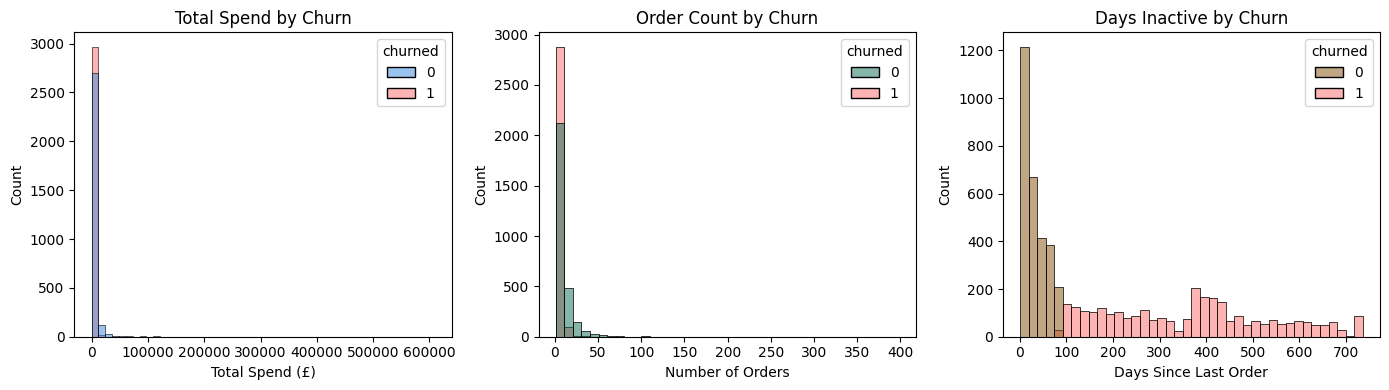

In [28]:
# churn vs non-churn distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# Total spend distribution by churn
sns.histplot(data=df, x='total_spend', hue='churned', bins=50, ax=axes[0], palette=['#378ADD', '#FF6B6B'])
axes[0].set_title('Total Spend by Churn')
axes[0].set_xlabel('Total Spend (£)')
# Order count distribution by churn
sns.histplot(data=df, x='order_count', hue='churned', bins=40, ax=axes[1], palette=['#0F6E56', '#FF6B6B'])
axes[1].set_title('Order Count by Churn')
axes[1].set_xlabel('Number of Orders')
# Days inactive distribution by churn
sns.histplot(data=df, x='days_inactive', hue='churned', bins=40, ax=axes[2], palette=['#854F0B', '#FF6B6B'])
axes[2].set_title('Days Inactive by Churn')
axes[2].set_xlabel('Days Since Last Order')
plt.tight_layout()
output_dir = os.path.join('..', 'data', 'clean')
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'eda_churn_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

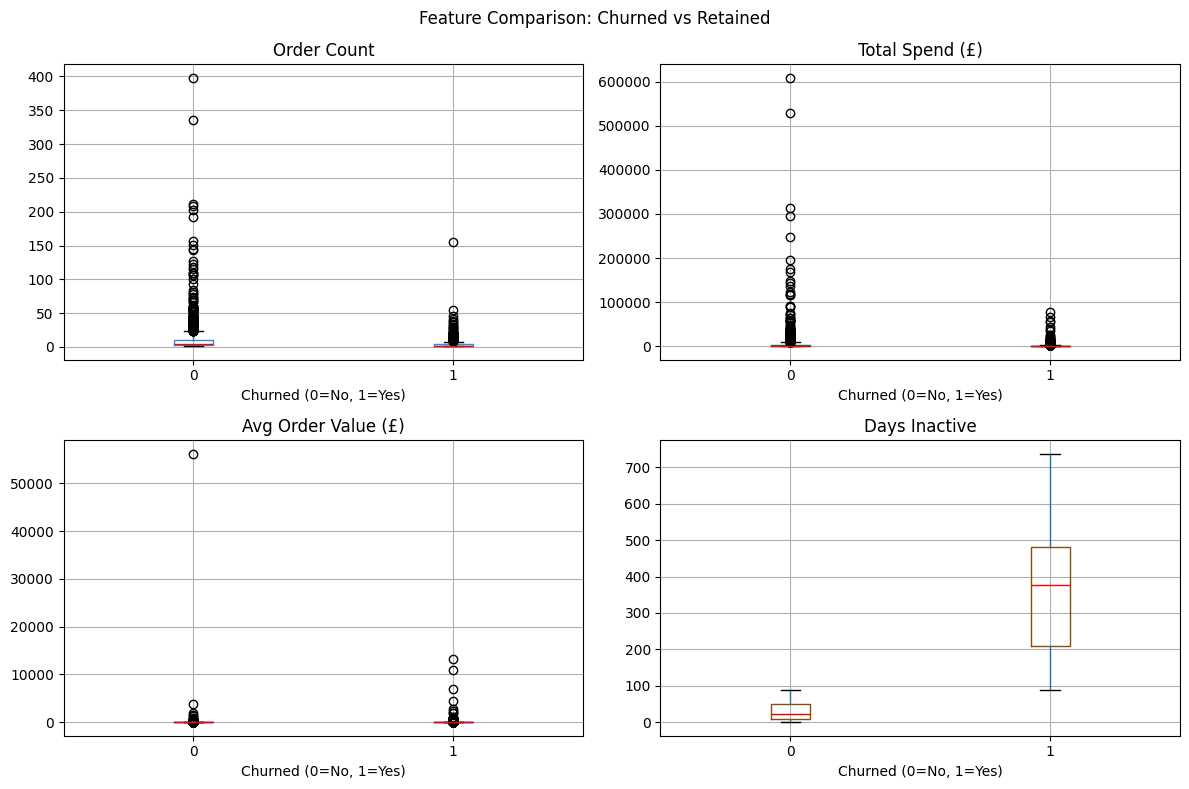

In [29]:
# churn vs non- churn features comparison
import os
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['order_count', 'total_spend', 'avg_order_value', 'days_inactive']
titles   = ['Order Count', 'Total Spend (£)', 'Avg Order Value (£)', 'Days Inactive']
colors   = ['#378ADD', '#0F6E56', '#534AB7', '#854F0B']

for ax, feat, title, color in zip(axes.flatten(), features, titles, colors):
    df.boxplot(column=feat, by='churned', ax=ax,
               boxprops=dict(color=color),
               medianprops=dict(color='red'))
    ax.set_title(title); ax.set_xlabel('Churned (0=No, 1=Yes)')

plt.suptitle('Feature Comparison: Churned vs Retained')
plt.tight_layout()
output_dir = os.path.join('..', 'data', 'clean')
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, 'eda_churn_boxplots.png'), dpi=150)
plt.show()

In [30]:
## ML MODELING

# prepare fetures & split train/test

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Feature selection — drop ID columns and target
features = ['order_count', 'total_spend', 'avg_order_value',
            'total_items', 'tenure_days', 'days_inactive']

X = df[features]
y = df['churned']

# Log-transform skewed features
X = X.copy()
X['total_spend']      = np.log1p(X['total_spend'])
X['total_items']      = np.log1p(X['total_items'])
X['avg_order_value']  = np.log1p(X['avg_order_value'])

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Churn rate train: {y_train.mean():.1%}")
print(f"Churn rate test:  {y_test.mean():.1%}")


Train: (4702, 6), Test: (1176, 6)
Churn rate train: 50.9%
Churn rate test:  50.9%


In [31]:
# ml model training & evaluation
#train the Random   Forest model 

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'  # handles churn imbalance
)

model.fit(X_train_sc, y_train)

print("✓ Model trained successfully")
print(f"  Trees: {model.n_estimators}")
print(f"  Features: {model.n_features_in_}")

✓ Model trained successfully
  Trees: 100
  Features: 6


In [32]:
# Evaluate model performance
from sklearn.metrics import (classification_report,
                             roc_auc_score, confusion_matrix)

y_pred      = model.predict(X_test_sc)
y_pred_prob = model.predict_proba(X_test_sc)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['Retained', 'Churned']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.3f}")

print()
print("=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives  (correct retained): {cm[0][0]}")
print(f"False Positives (wrong churn flag): {cm[0][1]}")
print(f"False Negatives (missed churners) : {cm[1][0]}")
print(f"True Positives  (correct churned) : {cm[1][1]}")

=== Classification Report ===
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00       578
     Churned       1.00      1.00      1.00       598

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

ROC-AUC Score: 1.000

=== Confusion Matrix ===
True Negatives  (correct retained): 578
False Positives (wrong churn flag): 0
False Negatives (missed churners) : 0
True Positives  (correct churned) : 598


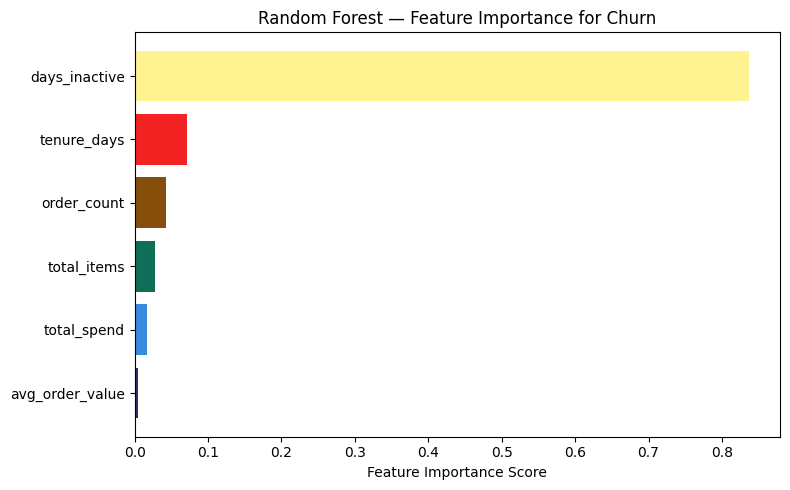

  days_inactive         : 0.8372
  tenure_days           : 0.0716
  order_count           : 0.0424
  total_items           : 0.0276
  total_spend           : 0.0167
  avg_order_value       : 0.0045


In [33]:
#plot feature importance
import matplotlib.pyplot as plt

importances = model.feature_importances_
feat_names  = features

# Sort by importance
idx = np.argsort(importances)[::-1]
sorted_feat = [feat_names[i] for i in idx]
sorted_imp  = importances[idx]

plt.figure(figsize=(8, 5))
bars = plt.barh(sorted_feat[::-1], sorted_imp[::-1],
                color=["#322C6C",'#378ADD','#0F6E56',
                       '#854F0B',"#F31414EF","#FFF291"])
plt.xlabel('Feature Importance Score')
plt.title('Random Forest — Feature Importance for Churn')
plt.tight_layout()
plt.savefig('../data/clean/feature_importance.png', dpi=150)
plt.show()

for f, i in zip(sorted_feat, sorted_imp):
    print(f"  {f:22}: {i:.4f}")

In [34]:
# add prediction & export for power BI dashboard

# Score ALL customers
X_all = df[features].copy()
X_all['total_spend']     = np.log1p(X_all['total_spend'])
X_all['total_items']     = np.log1p(X_all['total_items'])
X_all['avg_order_value'] = np.log1p(X_all['avg_order_value'])
X_all_sc = scaler.transform(X_all)

df['churn_probability'] = model.predict_proba(X_all_sc)[:, 1]
df['churn_prediction']  = model.predict(X_all_sc)

# Add risk band
df['risk_band'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

# Export
out = df[['customer_id','country','order_count','total_spend',
          'days_inactive','churned','churn_probability',
          'churn_prediction','risk_band']]
out.to_csv('../data/clean/churn_predictions.csv', index=False)

print("✓ Exported churn_predictions.csv")
print(df['risk_band'].value_counts())

✓ Exported churn_predictions.csv
risk_band
High      2989
Low       2052
Medium       0
Name: count, dtype: int64


In [35]:
df.head(10)

,customer_id,country,order_count,total_spend,avg_order_value,total_items,tenure_days,days_inactive,churned,churn_probability,churn_prediction,risk_band
0,12346.0,United Kingdom,12,77556.46,2281.07,74285.0,400,324,1,0.980214,1,High
1,12347.0,Iceland,8,5633.32,22.27,3286.0,402,1,0,0.005918,0,Low
2,12348.0,Finland,5,2019.40,39.60,2714.0,362,74,0,0.019327,0,Low
3,12349.0,Italy,4,4428.69,25.31,1624.0,570,17,0,0.005631,0,Low
4,12350.0,Norway,1,334.40,19.67,197.0,0,309,1,0.997905,1,High
5,12351.0,Unspecified,1,300.93,14.33,261.0,0,374,1,0.996731,1,High
6,12352.0,Norway,10,2849.84,27.67,724.0,356,35,0,0.024193,0,Low
7,12353.0,Bahrain,2,406.76,16.95,212.0,204,203,1,0.996966,1,High
8,12354.0,Spain,1,1079.40,18.61,530.0,0,231,1,0.996933,1,High
9,12355.0,Bahrain,2,947.61,27.07,543.0,353,213,1,0.992971,1,High
